In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lobster import *

In [2]:
ticker = "INTC"
message_path  = f"data/LOBSTER_SampleFile_{ticker}_2012-06-21_5/{ticker}_2012-06-21_34200000_57600000_message_5.csv"
orderbook_path = f"data/LOBSTER_SampleFile_{ticker}_2012-06-21_5/{ticker}_2012-06-21_34200000_57600000_orderbook_5.csv"
levels=5
K=5

msg, ob, qr, df = load_lobster_data(message_path, orderbook_path, levels=levels, K=K)
table1 = make_descriptive_table(df, K=5)
aes = compute_aes_by_level(df, K=5, lvl_col="lvl", size_col="size") 
df = normalize_by_aes(df, aes=aes, K=5)
df.head()

,time,delta_time,type,price,lvl,size,pref,P_1,Q_1,P_-1,...,P_-3,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5
0,34200.006241,0.006241,L,275200,1,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,0,274800.0,2,275600.0,1,274700.0,1
1,34200.006462,0.000221,L,275500,4,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1
2,34200.048864,0.042402,C,275000,-2,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1
3,34200.048883,0.000020,C,275100,-1,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1
4,34200.048989,0.000106,L,275000,-2,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1


In [30]:
df_sim = pd.read_parquet("mdqr_simulation_full.parquet")
df_sim = df_sim.rename(columns={"event_price": "price"})
df_sim["price"] *=50
df_sim["price"] += 275000
df_sim["time"]  += 34199
df_sim.head()

,time,type,lvl,size,Q_1,Q_-1,Q_2,Q_-2,Q_3,Q_-3,Q_4,Q_-4,Q_5,Q_-5,mid_price,price
0,34200.000009,L,-4,2.0,24.0,23.0,31.0,31.0,26.0,28.0,34.0,38.0,33.0,34.0,0.0,274800.0
1,34200.203118,C,3,1.0,24.0,23.0,31.0,31.0,25.0,28.0,34.0,38.0,33.0,34.0,0.0,275150.0
2,34200.232050,L,3,1.0,24.0,23.0,31.0,31.0,26.0,28.0,34.0,38.0,33.0,34.0,0.0,275150.0
3,34202.816539,C,-2,6.0,24.0,23.0,31.0,25.0,26.0,28.0,34.0,38.0,33.0,34.0,0.0,274900.0
4,34203.041954,C,5,1.0,24.0,23.0,31.0,25.0,26.0,28.0,34.0,38.0,32.0,34.0,0.0,275250.0


In [ ]:
volumeTraded = df.loc[df["type"] == "M", ["time", "size"]].copy()
volumeTraded["hour"] = volumeTraded["time"] // 3600
volumeTraded = volumeTraded.groupby("hour")["size"].sum().astype(float)
volumeTraded.loc[volumeTraded.index >= 10] /= 3600
volumeTraded.loc[volumeTraded.index < 10] /= 1800
volumeTraded

hour
9.0     2.851667
10.0    1.403056
11.0    1.519444
12.0    1.468333
13.0    1.392222
14.0    1.029722
15.0    3.878333
Name: size, dtype: float64

In [32]:
volumeTraded_sim = df_sim.loc[df_sim["type"] == "M", ["time", "size"]].copy()
volumeTraded_sim["hour"] = volumeTraded_sim["time"] // 3600
volumeTraded_sim = volumeTraded_sim.groupby("hour")["size"].sum().astype(float)
volumeTraded_sim.loc[volumeTraded_sim.index >= 10] /= 3600
volumeTraded_sim.loc[volumeTraded_sim.index < 10] /= 1800
volumeTraded_sim

hour
9.0     1.437222
10.0    1.003611
11.0    0.639167
12.0    0.658056
13.0    0.566667
14.0    0.845833
15.0    1.586111
Name: size, dtype: float64

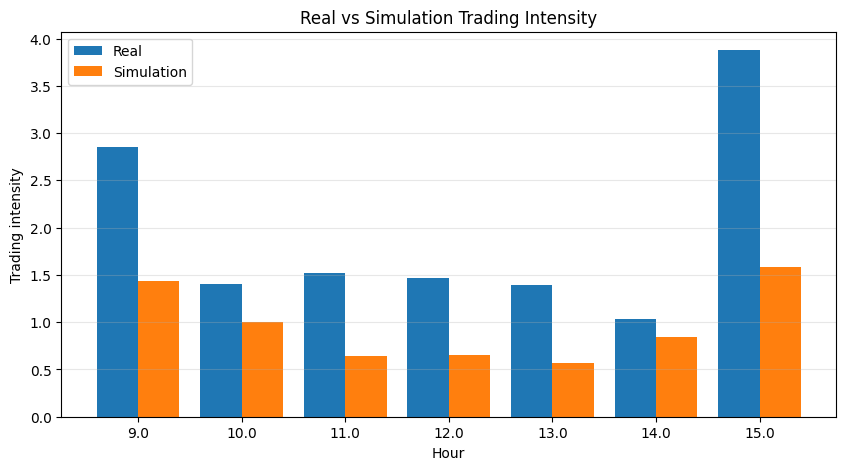

In [33]:
vt = volumeTraded.sort_index()
vt_sim = volumeTraded_sim.sort_index()

hours = vt.index
x = np.arange(len(hours))
width = 0.4

plt.figure(figsize=(10,5))

plt.bar(x - width/2, vt.values, width, label="Real")
plt.bar(x + width/2, vt_sim.values, width, label="Simulation")

plt.xticks(x, hours)
plt.xlabel("Hour")
plt.ylabel("Trading intensity")
plt.title("Real vs Simulation Trading Intensity")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()